# Spike coordination in simultaneously recorded neural pairs

Do two neurons recorded at the same time coordinate their spiking more during
**interactive-face** fixations than during non-interactive-face or object
fixations, and does that differ **within** a region versus **across** regions?

Everything here rests on per-fixation spike trains. Cross-correlating
condition-averaged PSTHs would measure shared rate structure, not coordination,
so every cross-correlation is computed on one fixation's two 1 ms trains and
only then averaged. The trains are **unsmoothed** — smoothing before
cross-correlation blurs exactly the fine timing this analysis exists to measure.

## Linear correlation, everything inside ±500 ms

The correlation is **linear** (zero-padded transform), the same statistic
`scipy.signal.correlate` computes and the same one the behavioural
cross-correlations use. At lag L only the `N − |L|` genuinely overlapping bins
contribute, so no spike is ever paired with one a full window away. A wrapping
(unpadded) transform would pair a spike at −500 ms with one at +500 ms and
report it as a coincidence at lag L — arithmetically convenient, physically
meaningless.

Linear correlation does taper: fewer bins contribute as |lag| grows, so a raw
correlation shrinks with lag for a purely mechanical reason. **This needs no
correction** — both nulls carry the identical taper and it cancels in the excess
and in every z-score. The per-lag overlap counts are stored with each output for
figures that want raw magnitudes on a comparable scale.

Widening the window is not an option: 95% of ±5 s surrounds contain at least one
*other* analysed fixation (median 5), before counting out-of-ROI fixations. Data
outside the window is not neutral baseline, so a shifted-window null would be a
comparison against a different behavioural condition rather than a null.
Everything — observed and both nulls — uses spikes inside ±500 ms.

## Reading the two nulls

Coordination is only meaningful relative to a null, and the two nulls answer
different questions:

| null | what it destroys | what it keeps | an excess means |
|---|---|---|---|
| **trial shuffle** | trial-by-trial covariation | each unit's fixation-locked rate profile | the two cells co-fluctuate from fixation to fixation |
| **circular shift** | fine temporal alignment within a fixation | that fixation's spike count and slow envelope | coordination finer than the shift, beyond slow co-modulation |

The circular shift rotates one train within the window, which does wrap. That is
acceptable *here and only here*: destroying temporal alignment is what a null is
for. It is the same reason wrapping is not acceptable in the observed statistic.

Each null draw is a **derangement** of the fixation index, so it is built from
exactly as many terms as the observed statistic. Estimating the null from all
`F*(F-1)` cross-fixation pairings would shrink its standard error and inflate
every z-score.

## Which number to compare

Two standardised quantities appear below and they are not interchangeable:

- **`z`** — the excess in units of the null SD of the fixation-averaged
  statistic. Grows with the square root of the fixation count. Use it for *is
  this coordinated at all*.
- **`effect`** — `z / sqrt(n_fixations)`, the excess in single-fixation null
  units. Its expectation does not depend on trial count. **Use it to compare
  conditions.** Interactive-face fixations outnumber non-interactive-face ones
  about five to one, so ranking conditions by `z` would rank them largely by
  trial count.

## Running this notebook

Section 1 checks what is built and can submit the SLURM array itself, then
section 2 rebuilds the summary tables. Everything after that reads those
summaries. The equivalent from a shell is:

    sbatch --array=0-41 hpc/ephys/run_fixation_pair_spike_coordination.sbatch
    python scripts/ephys/analysis/build_fixation_pair_spike_coordination_summary.py

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_spike_coordination as viz
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
cfg = load_config(str(DATASET_CFG_PATH))

SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig_settings = viz.PairCoordinationPlotSettings(output_dir=FIGURE_DIR)

#: The excess is standardised in single-fixation null units so that it does not
#: scale with how many fixations a condition contains.  Interactive-face
#: fixations outnumber non-interactive-face ones roughly five to one, so a
#: z-based comparison would rank conditions largely by trial count.
EFFECT_METRIC = "trial_shuffle_mean_effect_pm10ms"

print("summary dir:", SUMMARY_DIR)
print("figure dir :", FIGURE_DIR)

summary dir: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/summary
figure dir : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/figures


## 1. Build state

The per-session pair tables are built by a SLURM array over the 42 recording
dates. This reports what exists and what is missing; it does **not** queue
anything unless `SUBMIT_JOBS` is set to `True`, in which case it submits only
the incomplete dates and waits for the array to finish.

In [2]:
settings = psc.build_pair_spike_coordination_settings_from_config(
    dataset_cfg_path=str(DATASET_CFG_PATH),
    coordination_cfg_path=str(repo_root / "configs" / "ephys_fixation_pair_spike_coordination.yaml"),
)

# Submission is opt-in. The array job costs real cluster time and a notebook
# cell is easy to re-run by accident, so leaving this False only *reports* what
# is missing and prints the sbatch line to run.
SUBMIT_JOBS = False
WAIT_FOR_JOBS = True

per_date = psc.ensure_pair_coordination_built(
    settings,
    submit=SUBMIT_JOBS,
    wait=WAIT_FOR_JOBS,
    sbatch_path=repo_root / psc.DEFAULT_SBATCH_PATH,
    repo_root=repo_root,
)
display(per_date)

dates: 42 total, 1 complete, 41 incomplete
sessions: 9 of 417 built (0.05 GB on disk)
incomplete dates: ['01022019', '01032019', '01042019', '01052019', '01062019', '01072019', '01082019', '01092019', '01102019', '01112019', '01132019', '01142019', '01152019', '01162018', '01172018', '01172019', '01192018', '01302018', '02022018', '02042018', '02052018', '02062018', '02072018', '02082018', '02092018', '08242018', '08272018', '08282018', '08292018', '08302018', '08312018', '09042018', '09272018', '09292018', '09302018', '10012018', '10022018', '10032018', '10042018', '10092018', '10102018']

submit=False, so nothing was queued. To build these, run:
    sbatch --array=0-17,19-41 /gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/hpc/ephys/run_fixation_pair_spike_coordination.sbatch
or call this again with submit=True.


,date,n_sessions,n_built,total_mb,complete
0,01022019,10,0,0.000000,False
1,01032019,10,0,0.000000,False
2,01042019,10,0,0.000000,False
3,01052019,10,0,0.000000,False
4,01062019,10,0,0.000000,False
5,01072019,10,0,0.000000,False
6,01082019,10,0,0.000000,False
7,01092019,10,0,0.000000,False
8,01102019,10,0,0.000000,False
9,01112019,10,0,0.000000,False


Once every date is built, aggregate the per-session tables into the summary
files the rest of the notebook reads. This is the slow step — it touches every
session file — so set `REBUILD_SUMMARIES = False` to reuse what is on disk.

In [3]:
# Regenerate the summary tables from whatever is on disk. Skip if they are
# already current -- this reads every session file, so it is the slow step.
REBUILD_SUMMARIES = True

if REBUILD_SUMMARIES:
    _ = psc.run_summary_build(settings, metric=EFFECT_METRIC)
else:
    display(Markdown("_Using the summary tables already on disk._"))

summary tables written to /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/summary


## 2. Load

One row per (pair, condition). Traces stay on disk; the scalar summaries are
what every test below uses.

In [4]:
pairs, lags_ms = psc.load_pair_coordination(str(DATASET_CFG_PATH))
print(f"pair-condition rows: {len(pairs):,}")
print(f"lag axis: {lags_ms.size} bins, {lags_ms.min():.0f} to {lags_ms.max():.0f} ms")

inventory = psc.build_pair_inventory(pairs)
display(inventory)

pair-condition rows: 4,677
lag axis: 501 bins, -250 to 250 ms


,scope,condition,n_pairs,n_pairs_both_selective,n_dates,n_sessions,median_n_fixations
0,cross_region,face_interactive,883,414,1,9,35.0
1,cross_region,face_non_interactive,666,326,1,8,19.0
2,cross_region,object,891,428,1,9,37.0
3,within_region,face_interactive,810,356,1,9,35.0
4,within_region,face_non_interactive,605,279,1,8,19.0
5,within_region,object,822,367,1,9,37.0


## 3. Do the nulls behave?

Two checks, in order. The **identities** confirm the fast frequency-domain path returns exactly what a
brute-force sum over overlapping bins would — the speed-ups are only worth
having if they are provably the same number. The last row is deliberately *not*
an identity: it records how far the unpadded (wrapping) transform sits from the
linear one, so a silent loss of zero-padding would show up as a zero there.

The **sensitivity** check is the one that matters for interpretation. Four
synthetic pairs are pushed through the real computation:

- `independent` — no coupling. Both nulls should sit at zero. If they do not,
  every z below is inflated.
- `shared_rate` — the units share a per-fixation gain but are otherwise
  independent within a fixation. The trial-shuffle null **should** detect this;
  the circular-shift null should **not**.
- `synchronous` — a fraction of spikes copied at a fixed 4 ms lag. Both should
  detect it, at −4 ms.
- `common_zero_lag` — spikes injected into both units in the same 1 ms bin: the
  artifact signature, not a pairwise interaction.

Note `peak_z` is a maximum over ~200 lags, so it is inflated under the null by
construction (an uncoupled pair reaches ≈3). The windowed `mean_z_pm10ms`
columns are not maxima and are what the tests use.

,identity,max_abs_error,passes
0,mean over fixations == inverse transform of me...,2.220446e-16,True
1,trial-shuffle draw == same transform with a de...,1.665335e-16,True
2,circular-shift draw == linear correlation of t...,2.220446e-16,True
3,unpadded (wrapping) transform differs from the...,5.000000e-01,True


,scenario,trial_shuffle_peak_z,trial_shuffle_peak_lag_ms,trial_shuffle_mean_z_pm10ms,circular_shift_peak_z,circular_shift_peak_lag_ms,circular_shift_mean_z_pm10ms
0,independent,3.186,88.0,-0.105,3.435,88.0,0.546
1,shared_rate,5.169,33.0,2.025,3.391,33.0,0.641
2,synchronous,72.364,-4.0,3.623,64.343,-4.0,3.955
3,common_zero_lag,88.928,0.0,4.446,85.206,0.0,4.667


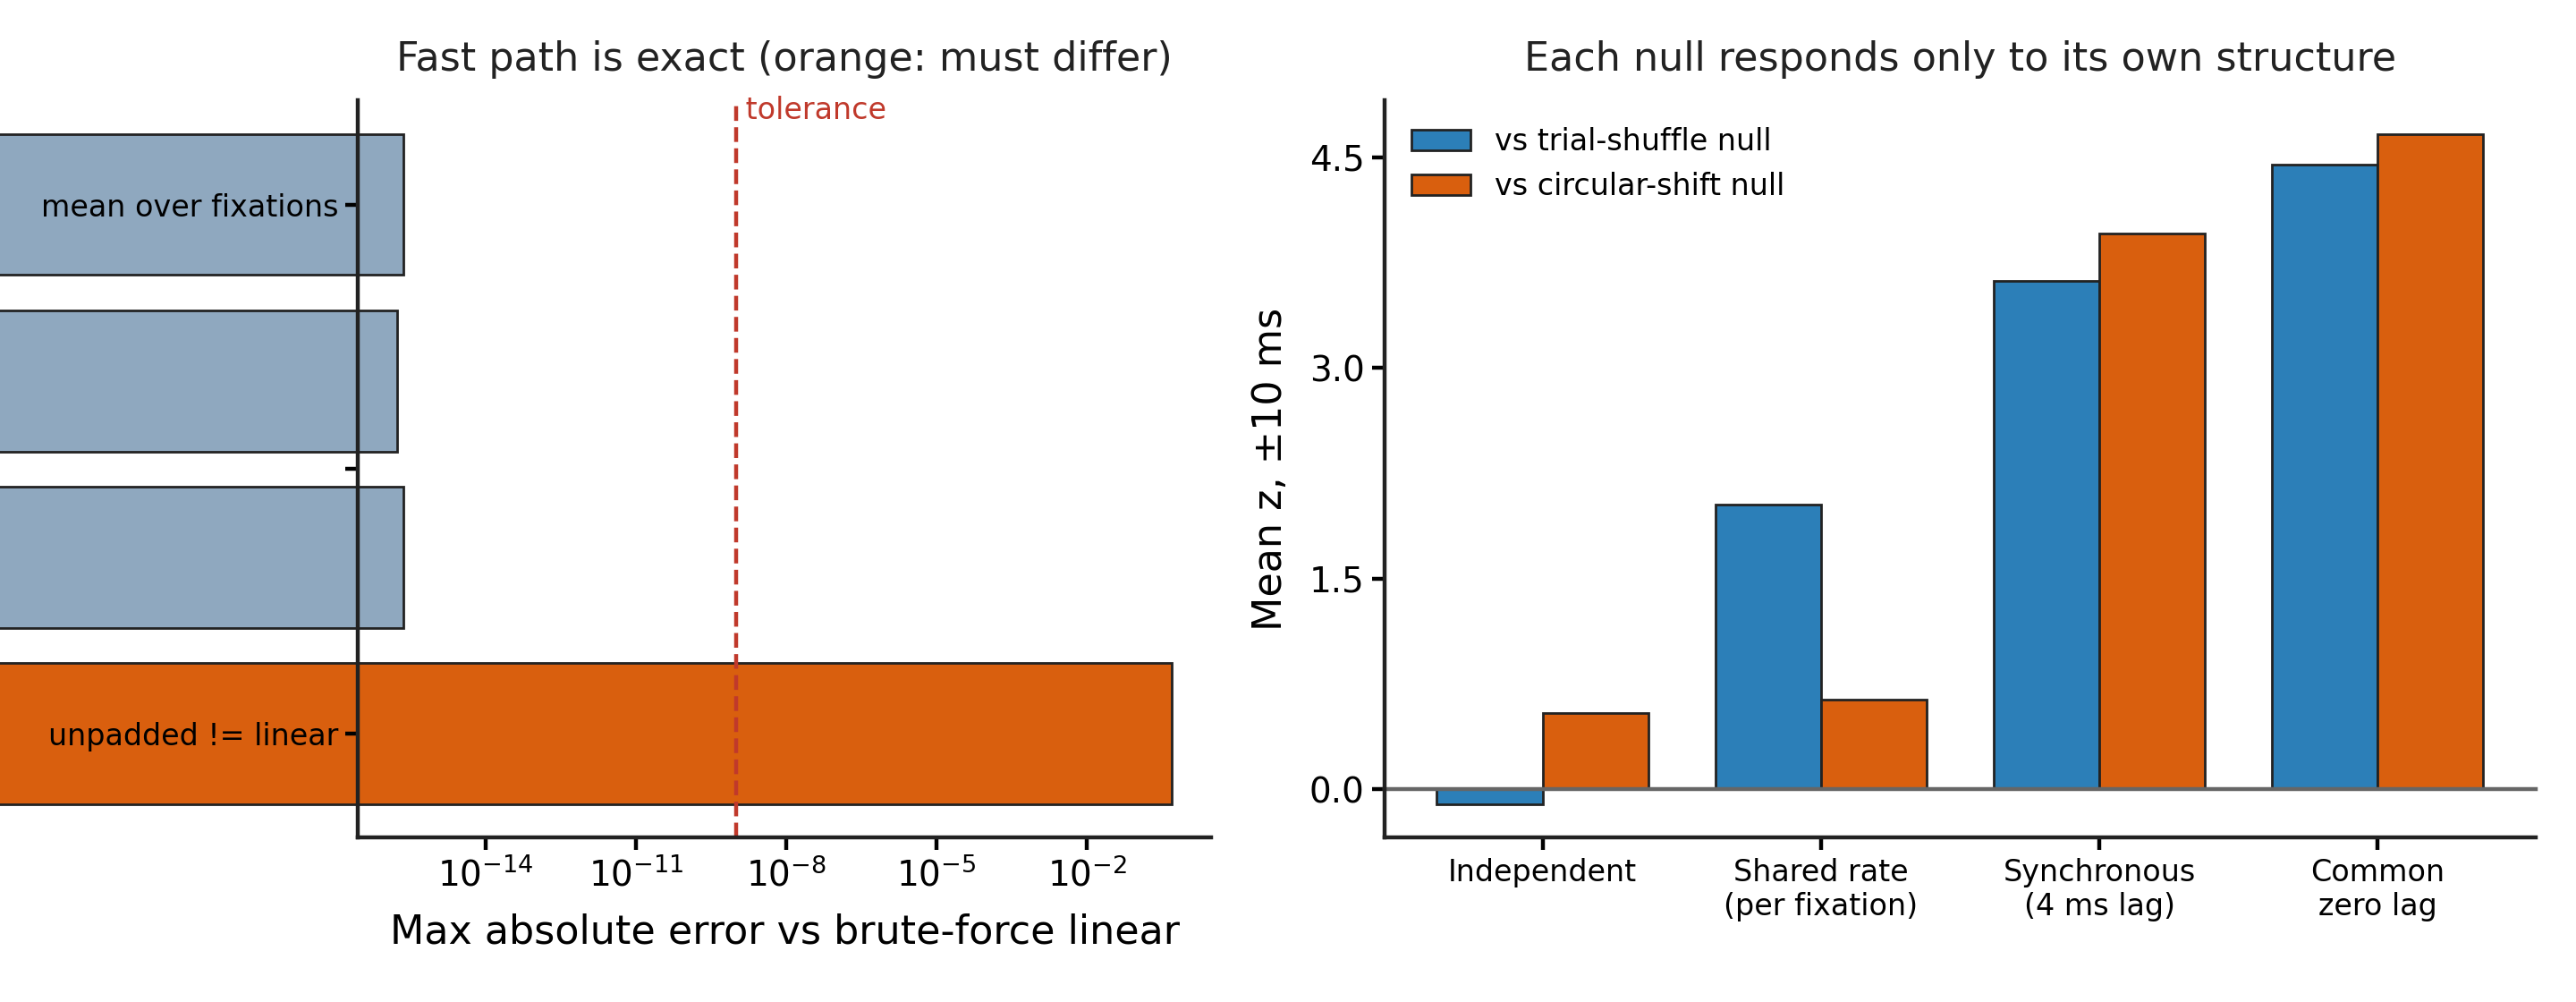

In [5]:
identities = psc.verify_null_identities()
display(identities)
assert identities["passes"].all(), "Null construction identities failed."

sensitivity = psc.verify_null_sensitivity()
display(sensitivity.round(3))

fig, paths = viz.plot_null_validation(identities, sensitivity, fig_settings)
display(Image(filename=str(paths["png"])))

## 4. Is there any coordination above null to begin with?

Before asking whether conditions differ, ask whether there is anything to
differ. A one-sample Wilcoxon signed-rank test of the per-pair excess against
zero — zero being the null's own expectation.

,scope,condition,n_pairs,mean_excess,median_excess,statistic,p_value
0,cross_region,face_interactive,883,0.0593,0.0353,310315.0,0.0
1,cross_region,face_non_interactive,666,0.0499,0.0140,149035.0,0.0
2,cross_region,object,891,0.0517,0.0222,292940.0,0.0
3,within_region,face_interactive,810,0.0752,0.0473,270175.0,0.0
4,within_region,face_non_interactive,605,0.0829,0.0312,134552.0,0.0
5,within_region,object,822,0.0621,0.0300,259232.0,0.0


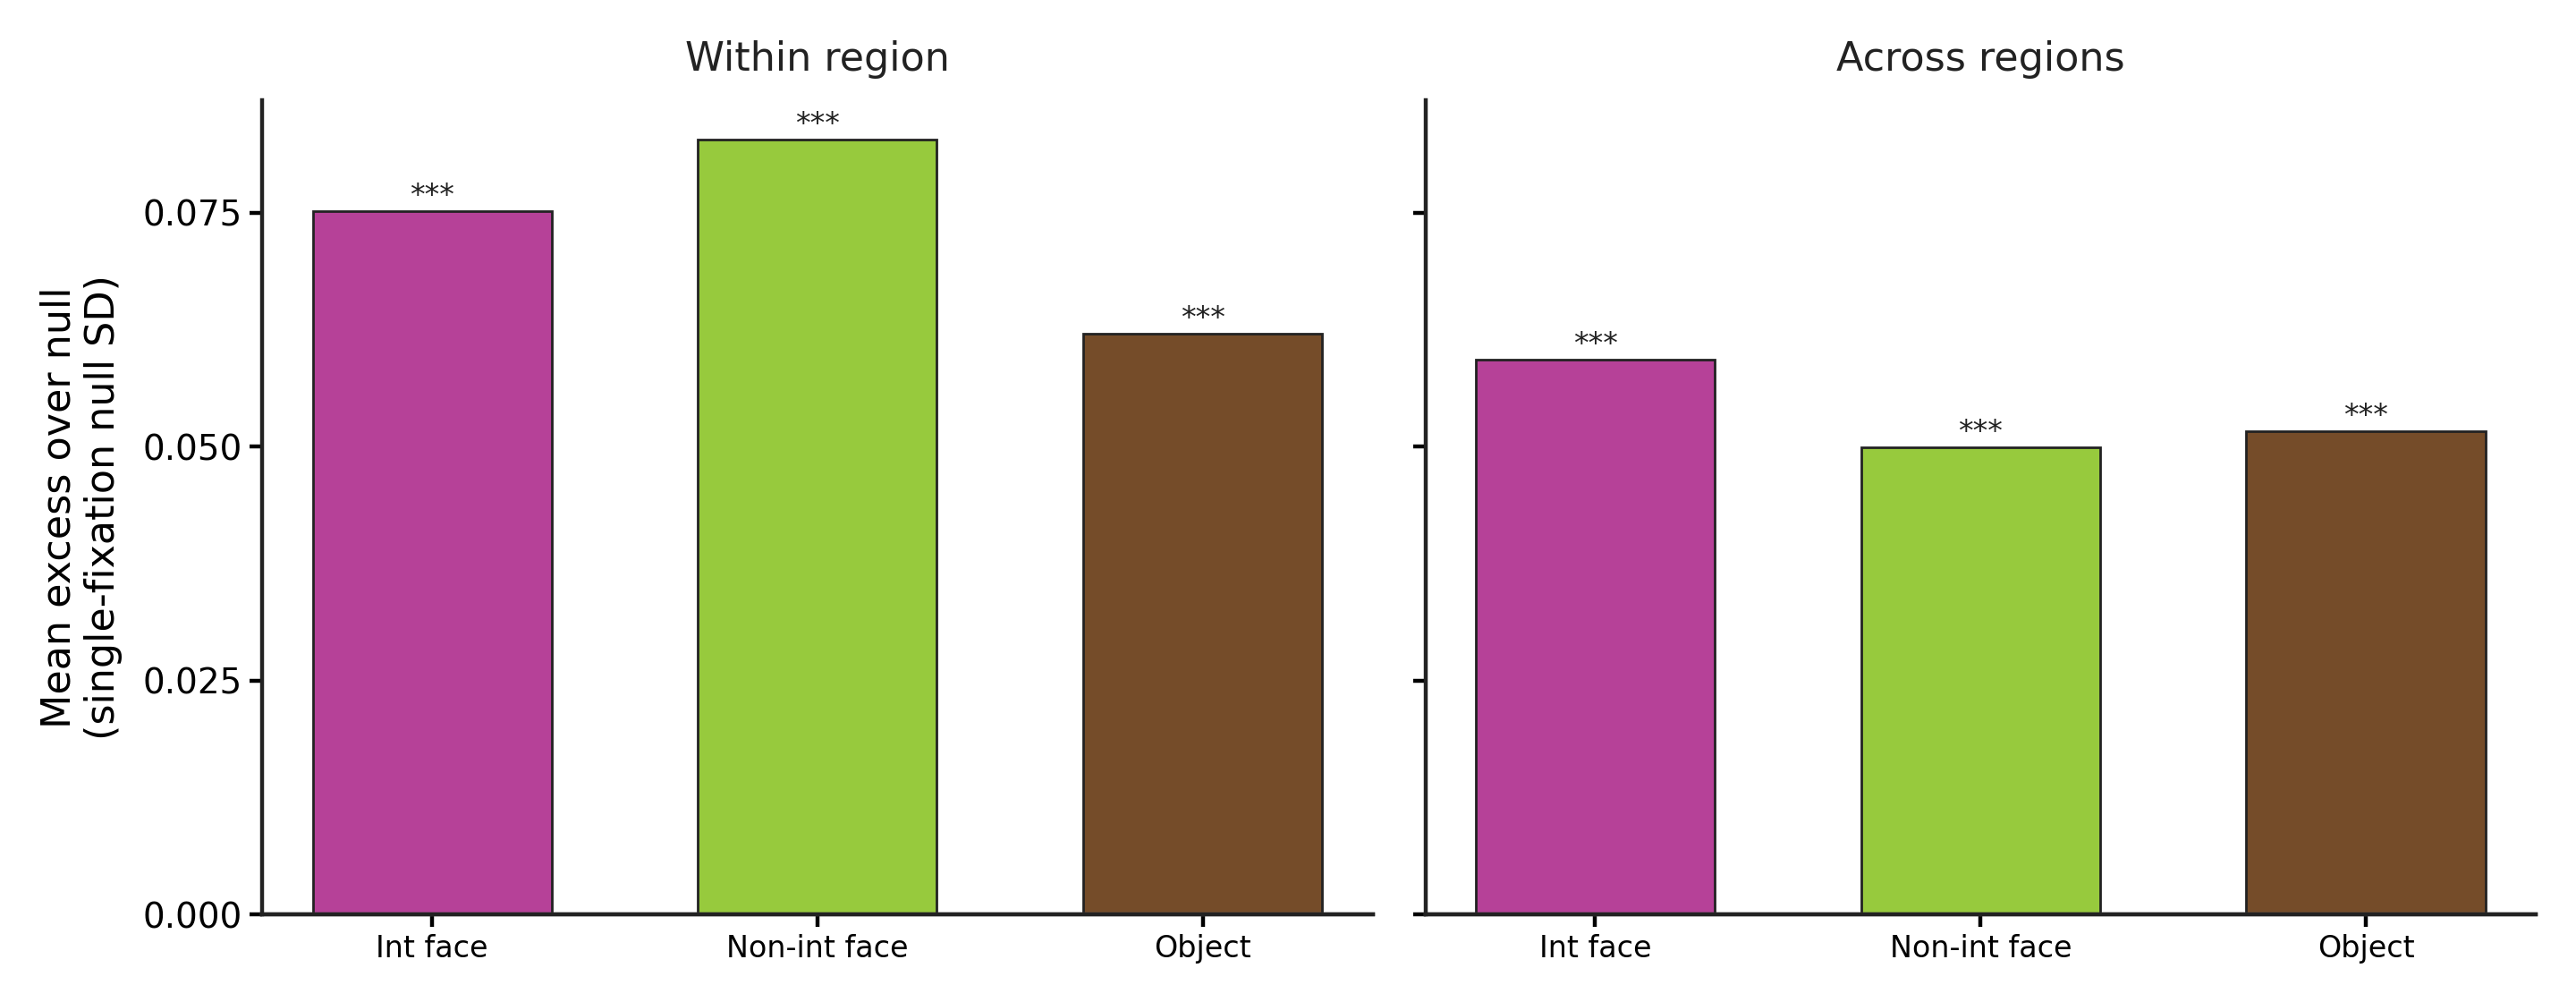

In [6]:
vs_null = psc.test_against_null(pairs, metric=EFFECT_METRIC)
display(vs_null.round(4))

fig, paths = viz.plot_excess_vs_null(vs_null, fig_settings)
display(Image(filename=str(paths["png"])))

## 5. Where in lag does the coordination sit?

Mean per-lag excess across pairs, one panel per scope. Distance from zero *is*
the coordination; bands are standard error across pairs.

Compare the two nulls: structure present against the trial-shuffle null but
absent against the circular-shift null is slow co-fluctuation rather than fine
synchrony.

**vs trial-shuffle null** — co-fluctuation across fixations

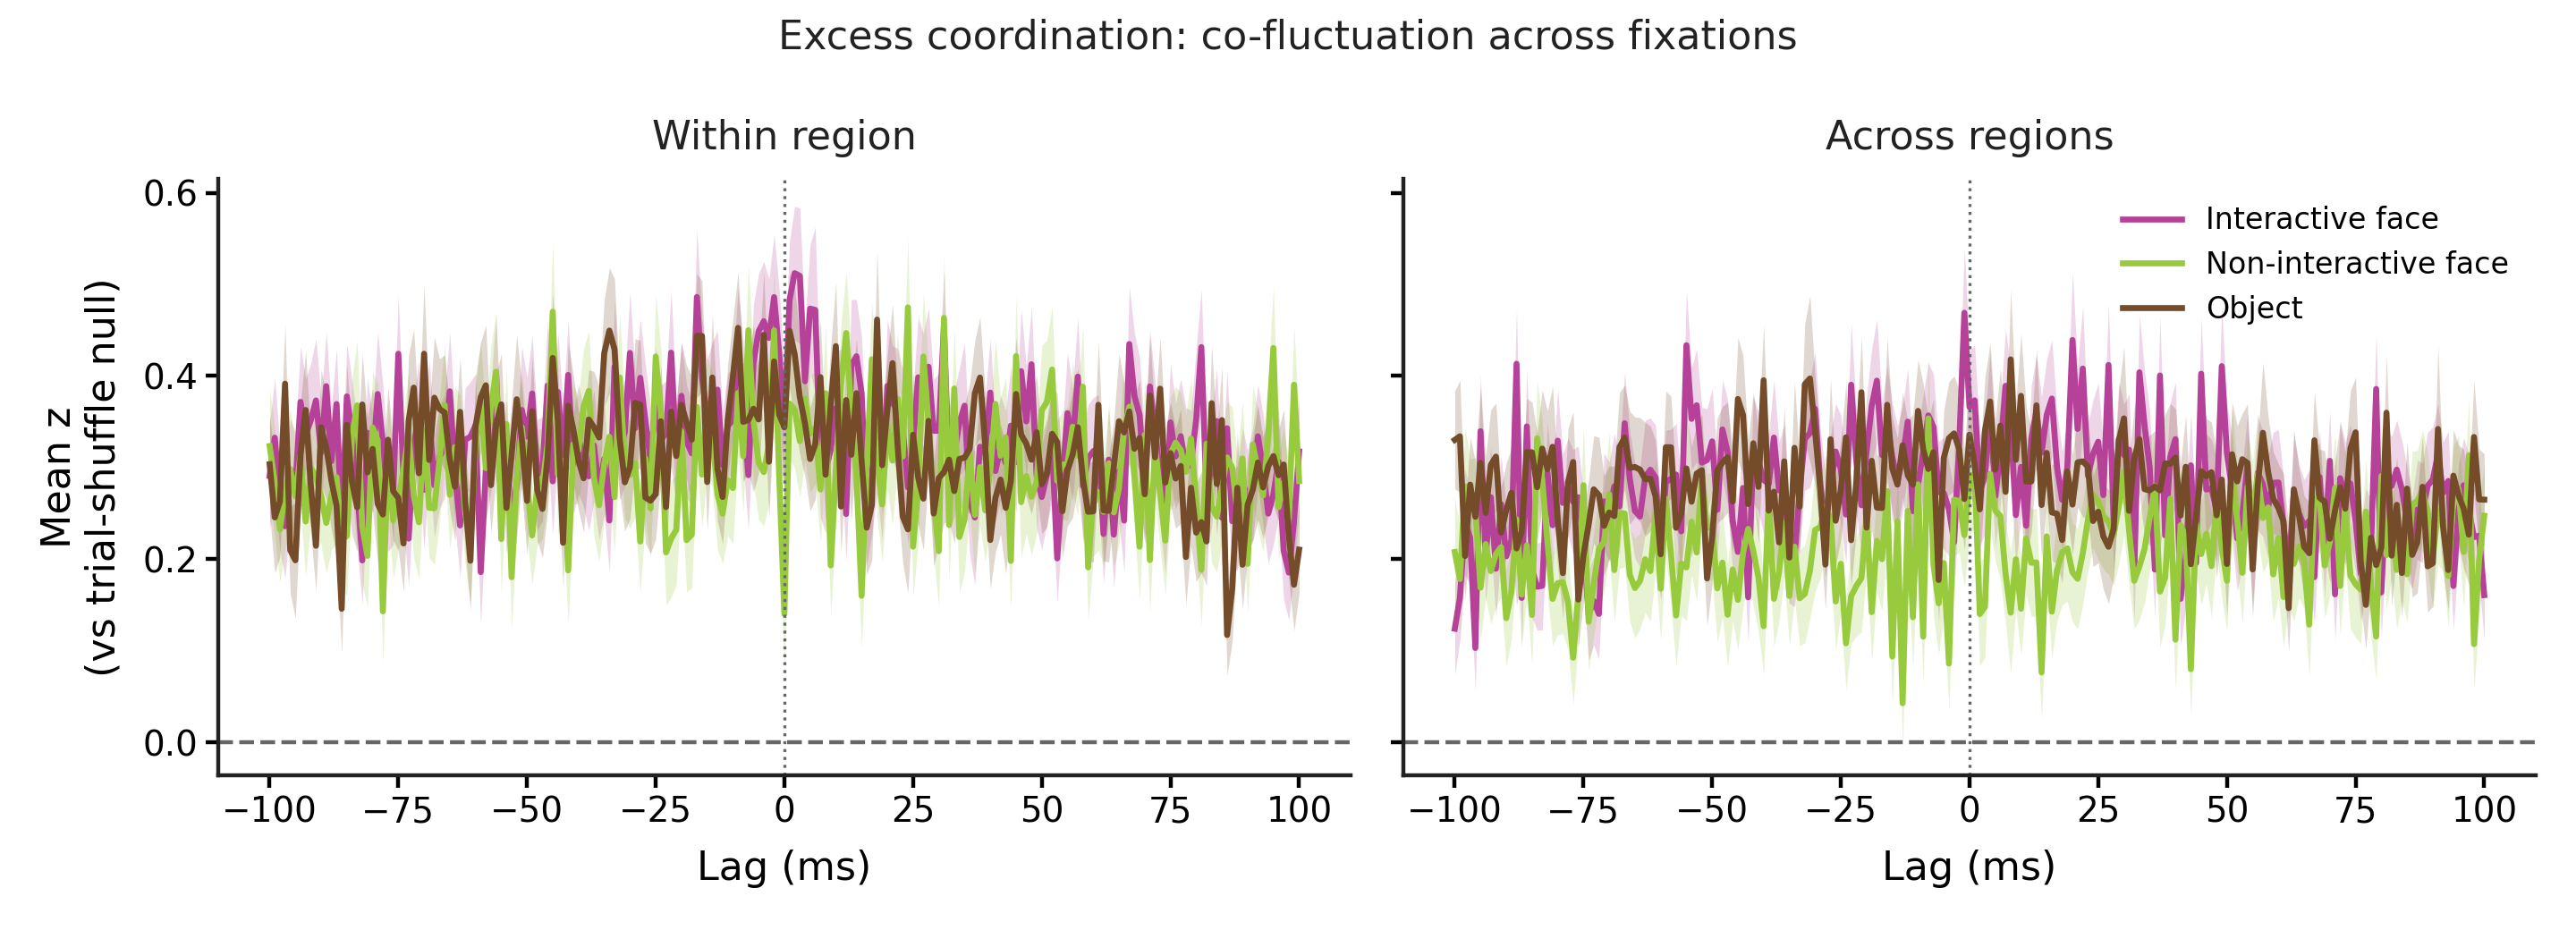

**vs circular-shift null** — fine-timing alignment within a fixation

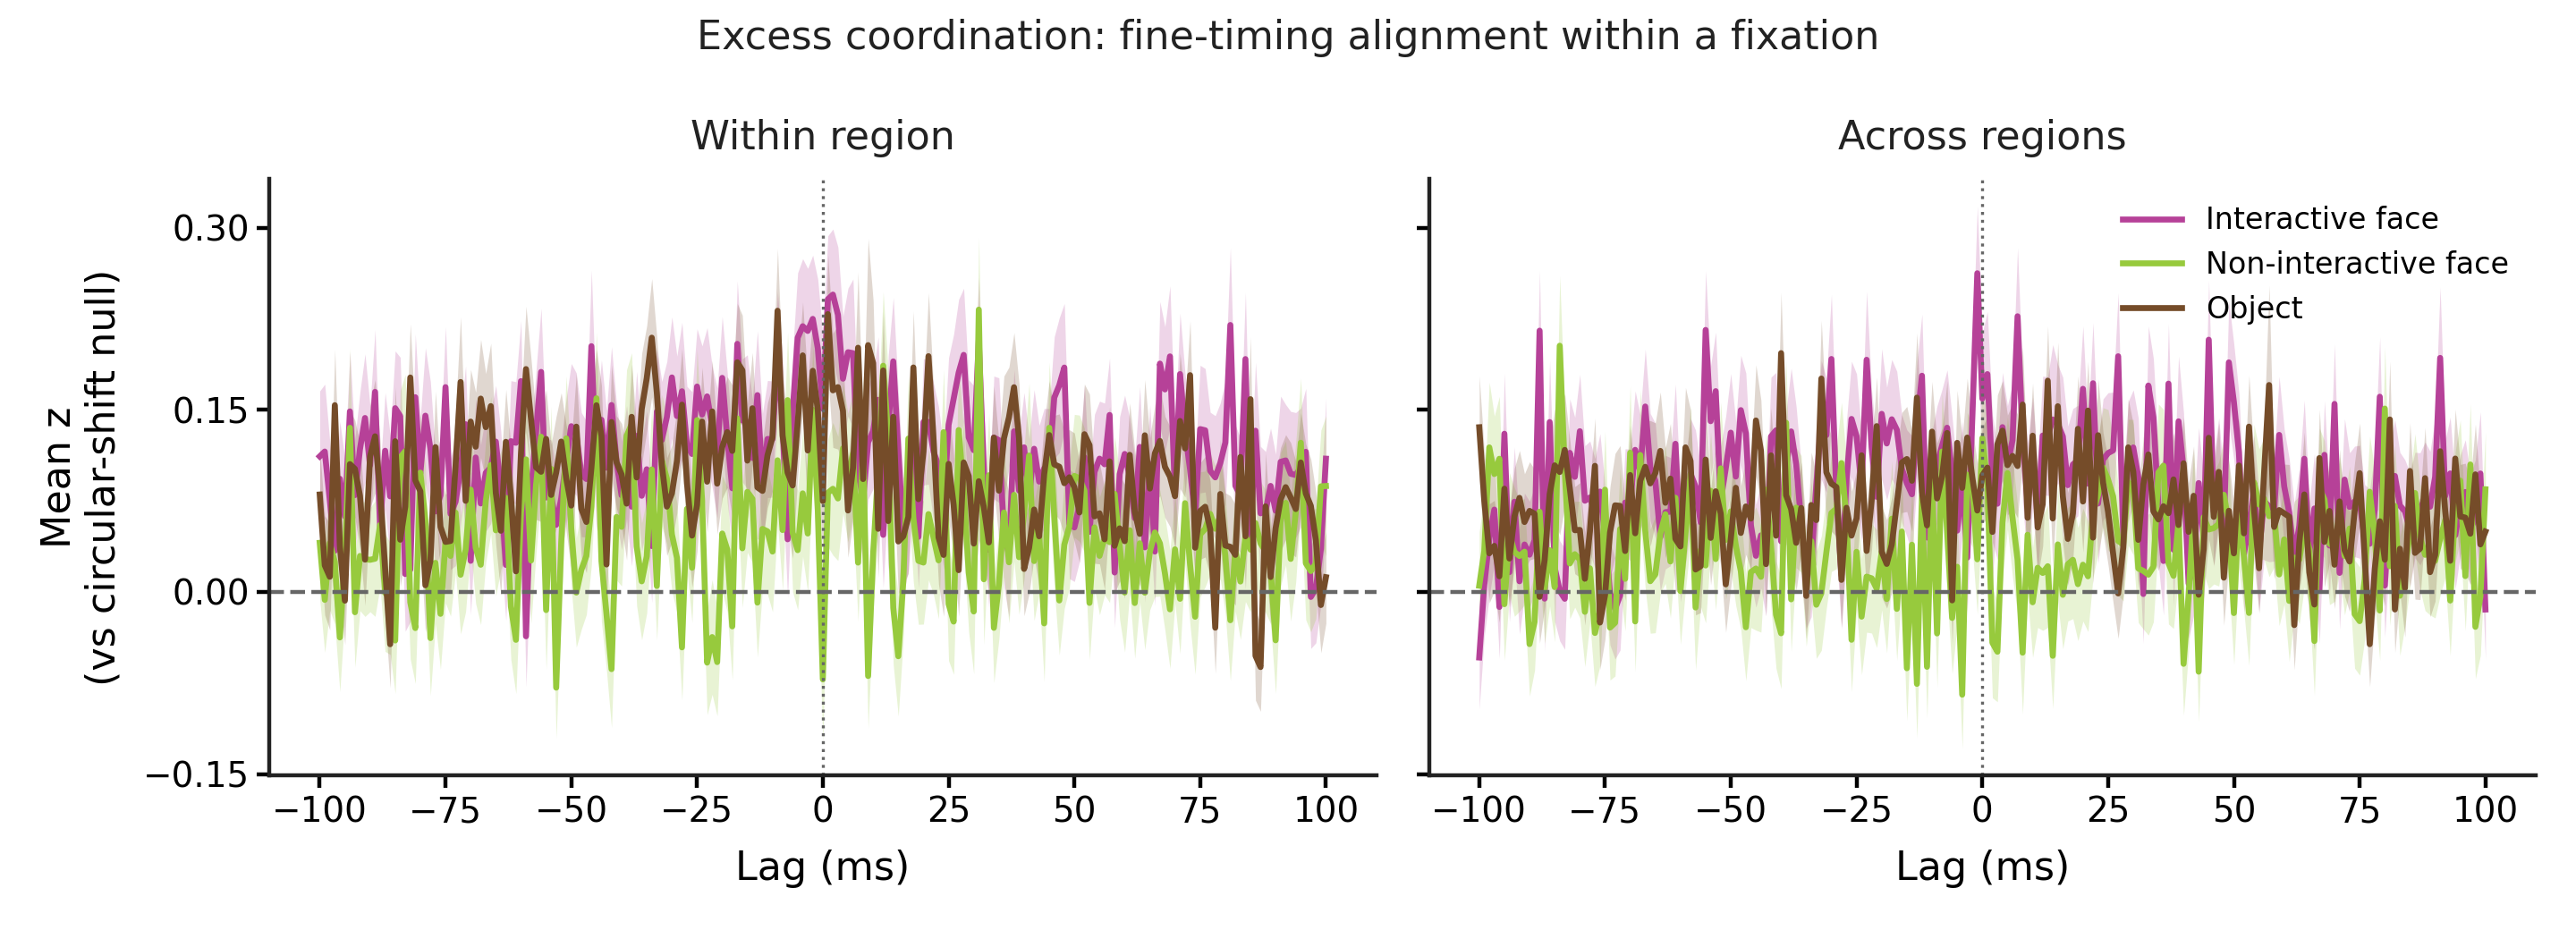

In [7]:
by_scope = pd.read_pickle(SUMMARY_DIR / "group_z_traces_by_scope.pkl")

for null_name in ("trial_shuffle", "circular_shift"):
    fig, paths = viz.plot_group_z_traces(by_scope, fig_settings, null_name=null_name)
    display(Markdown(f"**{viz.NULL_LABELS[null_name]}** — {viz.NULL_MEANINGS[null_name]}"))
    display(Image(filename=str(paths["png"])))

## 6. Condition effects, by region pair

Bootstrap confidence intervals on the per-pair effect, broken out by region and
region pair.

,scope,region_pair,condition,n_pairs,n_pairs_finite,mean,sem,median,ci_low,ci_high,median_n_fixations,frac_pairs_above_null,mean_z
0,cross_region,accg-bla,face_interactive,883,883,0.0593,0.0036,0.0353,0.0524,0.0665,35.0,0.0159,0.3219
1,cross_region,accg-bla,face_non_interactive,666,666,0.0499,0.0053,0.0140,0.0397,0.0603,19.0,0.0330,0.2111
2,cross_region,accg-bla,object,891,891,0.0517,0.0057,0.0222,0.0410,0.0636,37.0,0.0236,0.3129
3,within_region,accg,face_interactive,334,334,0.1262,0.0075,0.1001,0.1118,0.1411,35.0,0.0509,0.7004
4,within_region,accg,face_non_interactive,258,258,0.1587,0.0127,0.1077,0.1356,0.1841,19.0,0.0465,0.6066
5,within_region,accg,object,325,325,0.1176,0.0131,0.0683,0.0947,0.1435,37.0,0.0615,0.7008
6,within_region,bla,face_interactive,476,476,0.0395,0.0044,0.0184,0.0308,0.0482,35.0,0.0147,0.2150
7,within_region,bla,face_non_interactive,347,347,0.0265,0.0062,-0.0055,0.0143,0.0392,19.0,0.0086,0.1210
8,within_region,bla,object,497,497,0.0257,0.0041,0.0063,0.0179,0.0341,37.0,0.0141,0.1586


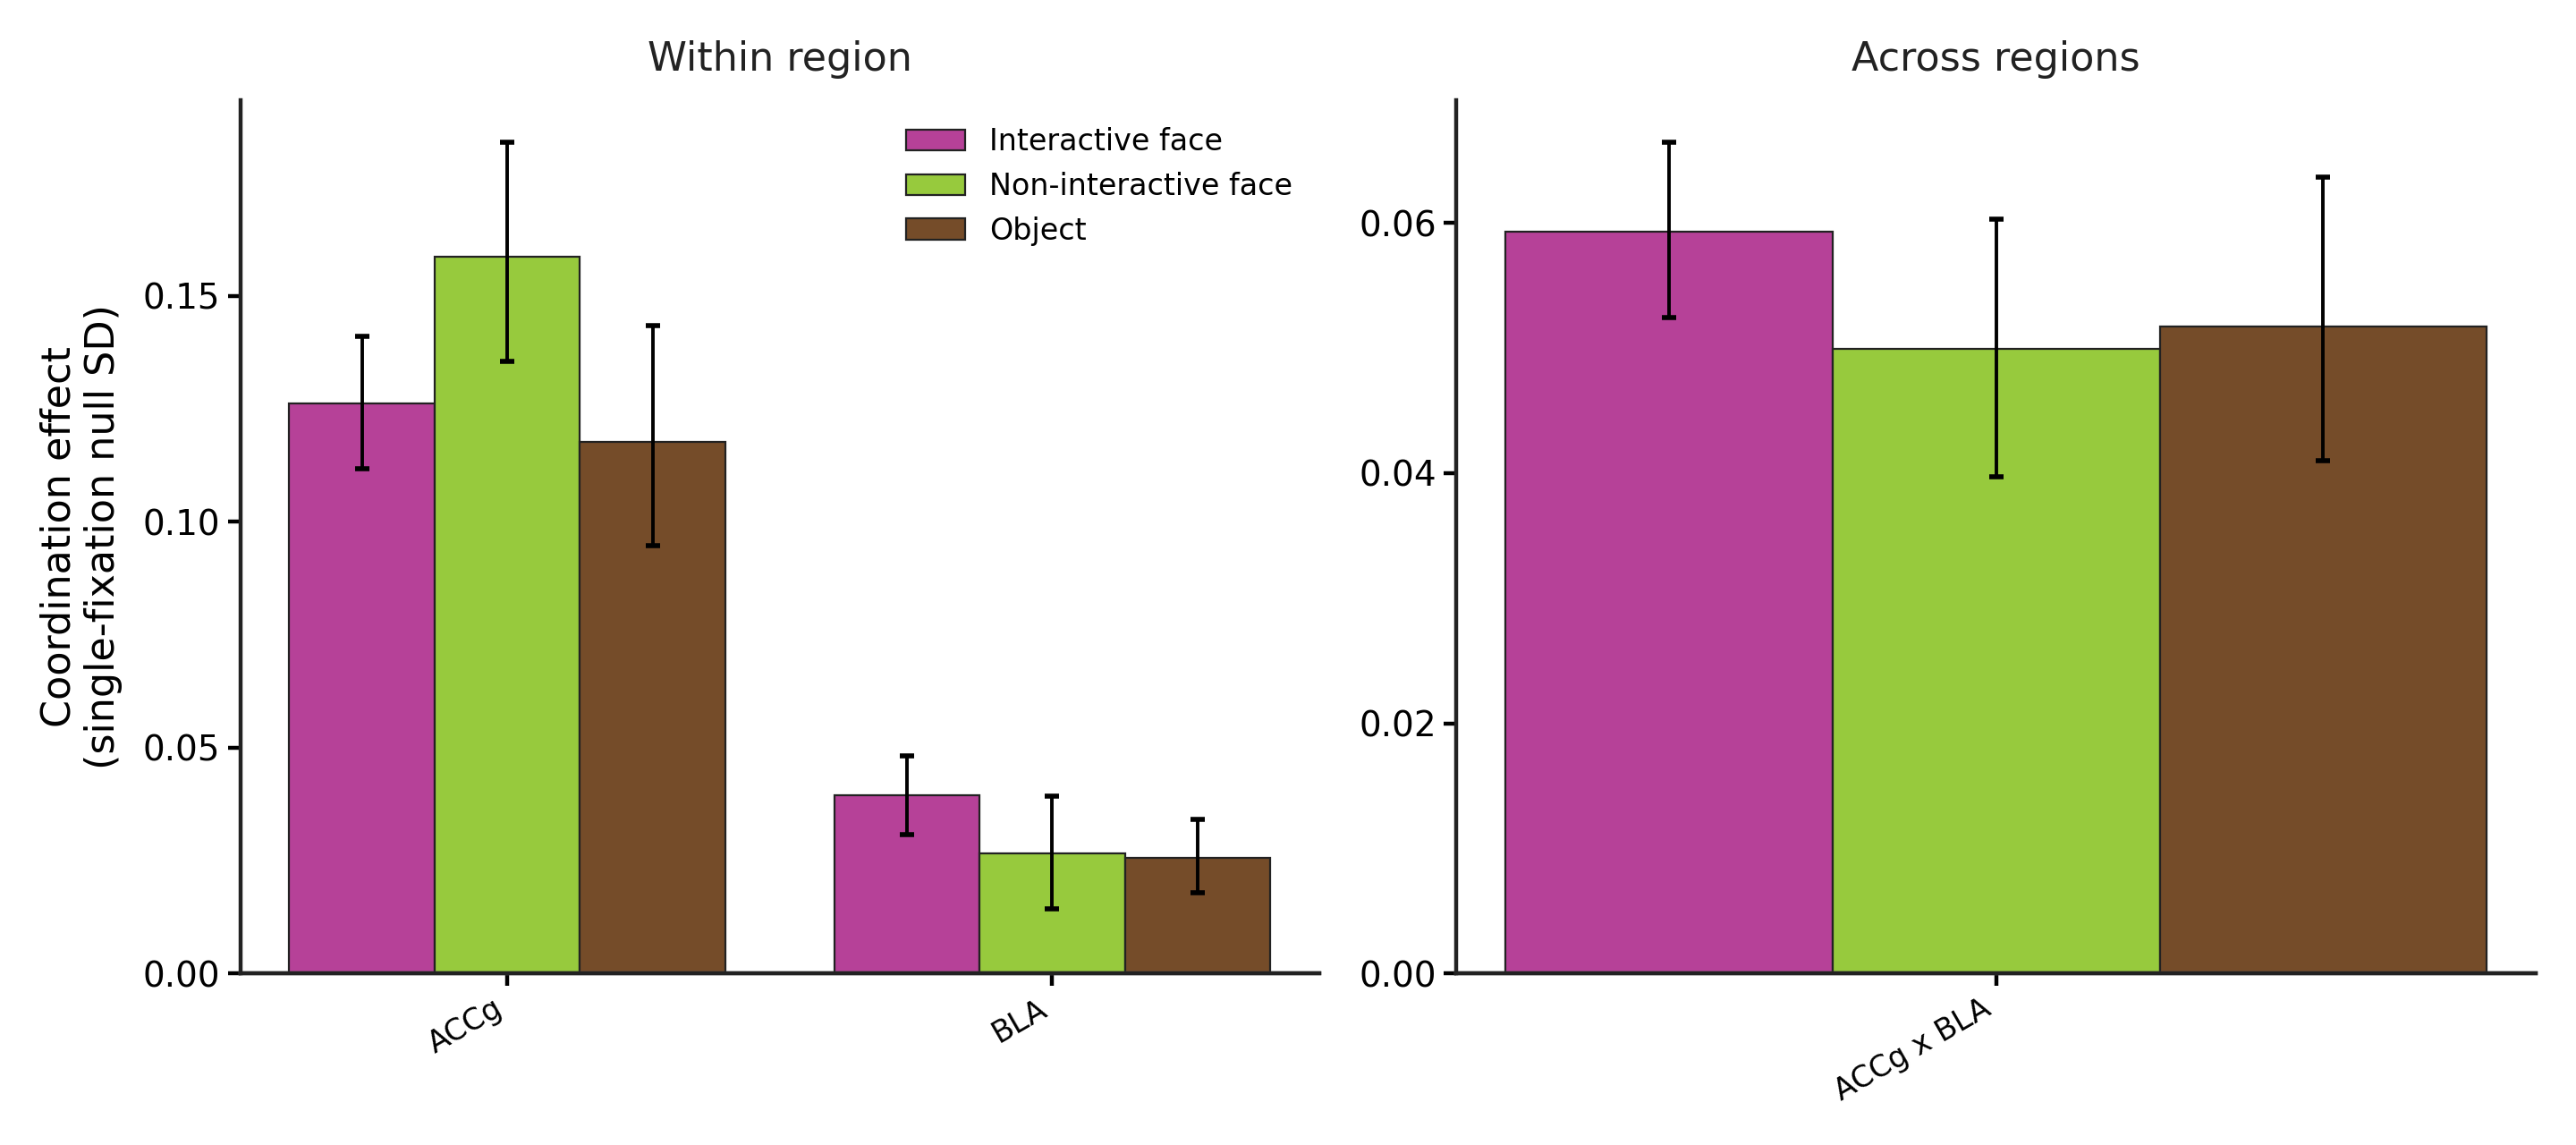

In [8]:
summary = psc.summarize_coordination(pairs, metric=EFFECT_METRIC)
display(summary.round(4))

fig, paths = viz.plot_condition_effects(summary, fig_settings)
display(Image(filename=str(paths["png"])))

## 7. Does interactive face change coordination?

The comparison is **paired within pair**: the same two neurons, the same
electrodes, the same session, differing only in which fixations were used. That
removes pair identity, firing rate and recording quality as explanations in one
step, which a comparison across separate pair populations could not do.
Benjamini–Hochberg correction across the reported contrasts.

,scope,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,face_interactive,face_non_interactive,639,0.0505,0.0517,-0.0012,91707.0,0.0241,0.0829,0.0481,True,fdr_bh
1,cross_region,face_interactive,object,844,0.0619,0.0552,0.0067,149931.0,0.0001,0.1090,0.0002,True,fdr_bh
2,cross_region,face_non_interactive,object,648,0.0496,0.0510,-0.0014,97589.0,0.1133,-0.0833,0.1360,False,fdr_bh
3,within_region,face_interactive,face_non_interactive,576,0.0678,0.0880,-0.0202,81758.0,0.7393,-0.0069,0.7393,False,fdr_bh
4,within_region,face_interactive,object,771,0.0781,0.0650,0.0132,123038.0,0.0000,0.0973,0.0002,True,fdr_bh
5,within_region,face_non_interactive,object,586,0.0854,0.0615,0.0240,79088.0,0.0921,0.0307,0.1360,False,fdr_bh


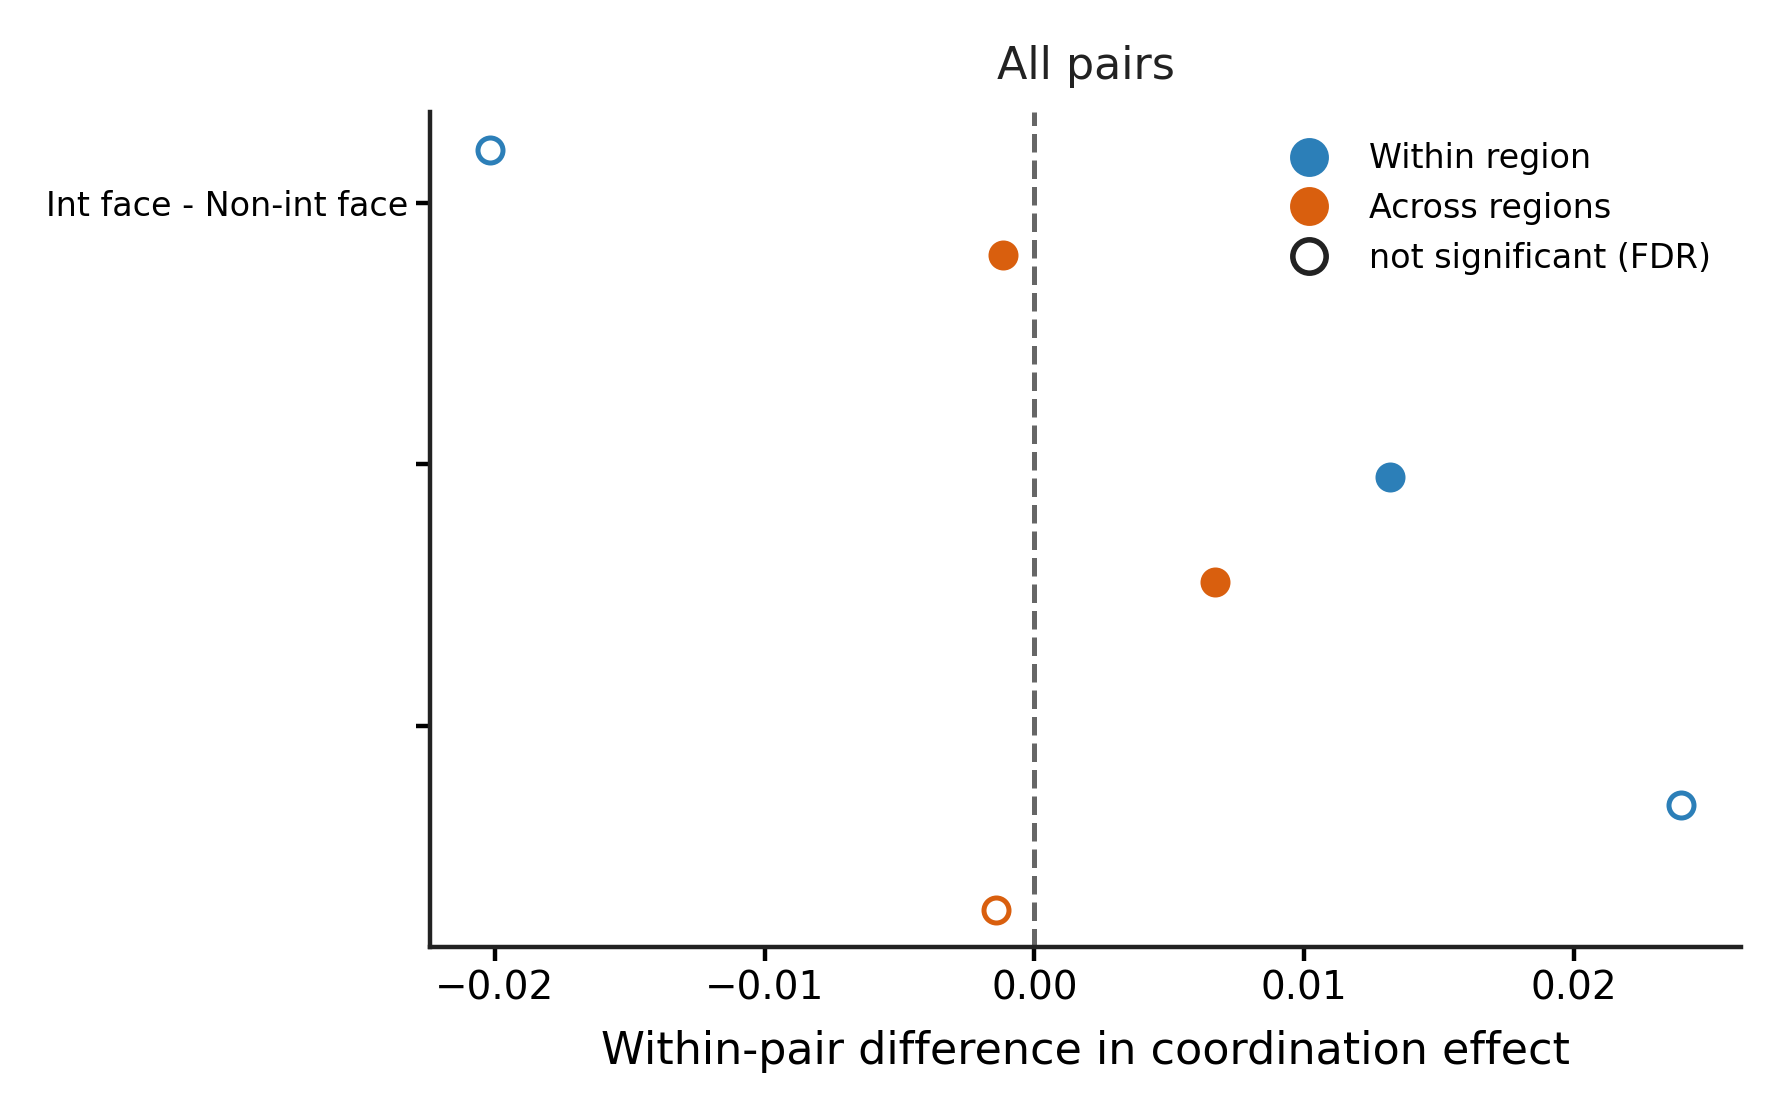

In [9]:
comparisons = psc.compare_conditions(pairs, metric=EFFECT_METRIC)
display(comparisons.round(4))

fig, paths = viz.plot_condition_contrasts(comparisons, fig_settings, label="All pairs")
display(Image(filename=str(paths["png"])))

## 8. Control: trial-count matching

The `effect` metric is already constructed not to scale with trial count. This
is the direct check on the same confound: every pair recomputed on a common
fixation count across conditions.

**If a condition difference survives here, trial count is not driving it.**

,scope,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,face_interactive,face_non_interactive,639,0.0440,0.0518,-0.0078,98353.0,0.4051,0.0548,0.4051,False,fdr_bh
1,cross_region,face_interactive,object,756,0.0382,0.0785,-0.0403,128564.5,0.0251,-0.0810,0.0674,False,fdr_bh
2,cross_region,face_non_interactive,object,648,0.0493,0.0708,-0.0215,94455.0,0.0250,-0.1204,0.0674,False,fdr_bh
3,within_region,face_interactive,face_non_interactive,576,0.0624,0.0953,-0.0329,75074.0,0.0449,-0.0451,0.0674,False,fdr_bh
4,within_region,face_interactive,object,688,0.0558,0.0821,-0.0263,109340.5,0.1485,-0.0395,0.1782,False,fdr_bh
5,within_region,face_non_interactive,object,586,0.0930,0.0736,0.0195,77388.0,0.0358,0.0341,0.0674,False,fdr_bh


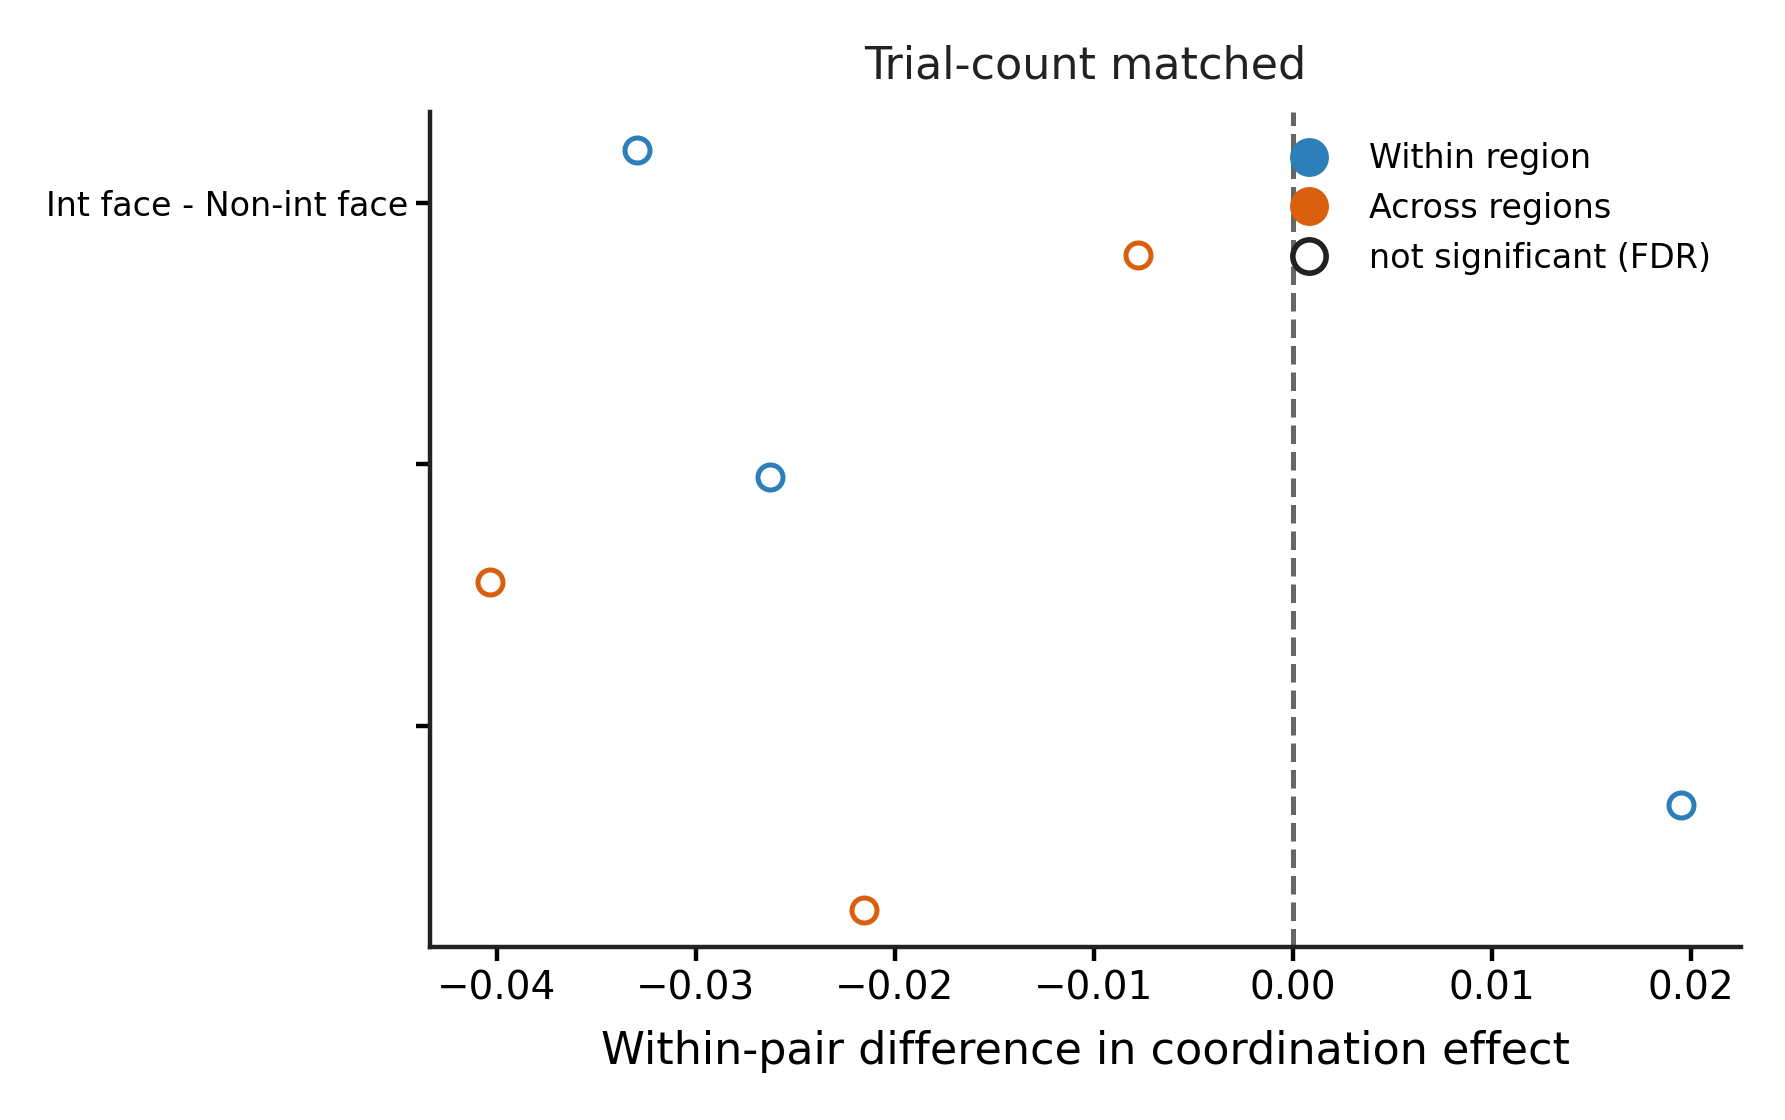

,scope,condition_a,condition_b,mean_difference_full,mean_difference_matched,significant_full,significant_matched
0,cross_region,face_interactive,face_non_interactive,-0.0012,-0.0078,True,False
1,cross_region,face_interactive,object,0.0067,-0.0403,True,False
2,cross_region,face_non_interactive,object,-0.0014,-0.0215,False,False
3,within_region,face_interactive,face_non_interactive,-0.0202,-0.0329,False,False
4,within_region,face_interactive,object,0.0132,-0.0263,True,False
5,within_region,face_non_interactive,object,0.0240,0.0195,False,False


In [10]:
matched_metric = EFFECT_METRIC + "_matched"
if matched_metric in pairs.columns and pairs[matched_metric].notna().any():
    matched = psc.compare_conditions(pairs, metric=matched_metric)
    display(matched.round(4))
    fig, paths = viz.plot_condition_contrasts(
        matched, fig_settings, label="Trial-count matched", stem="fig04b_condition_contrasts_matched"
    )
    display(Image(filename=str(paths["png"])))
    merged = comparisons.merge(
        matched, on=["scope", "condition_a", "condition_b"], suffixes=("_full", "_matched")
    )
    display(
        merged.loc[
            :,
            ["scope", "condition_a", "condition_b",
             "mean_difference_full", "mean_difference_matched",
             "significant_full", "significant_matched"],
        ].round(4)
    )
else:
    display(Markdown("_Trial-count-matched columns are absent; rebuild with `trial_match_conditions: true`._"))

## 9. Restricting to FDR-selective units

Pairs where **both** units are significantly selective for at least one
fixation-condition contrast (FDR-corrected, `three_condition_core`).

This is a sensitivity check, not independent confirmation — selecting units by a
condition contrast and then asking whether coordination differs by condition is
circular. What it can legitimately show is whether any effect is carried by the
selective subset or is distributed across the population.

pairs with both units FDR-selective: 2,170 of 4,677 (46.4%)


,scope,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,face_interactive,face_non_interactive,312,0.0391,0.0384,0.0006,22383.0,0.2028,0.0449,0.3518,False,fdr_bh
1,cross_region,face_interactive,object,400,0.0505,0.0351,0.0154,36218.0,0.0934,0.0550,0.2802,False,fdr_bh
2,cross_region,face_non_interactive,object,326,0.0356,0.0321,0.0035,24762.0,0.2675,-0.0736,0.3518,False,fdr_bh
3,within_region,face_interactive,face_non_interactive,267,0.0728,0.0888,-0.0159,17822.0,0.9577,0.0412,0.9577,False,fdr_bh
4,within_region,face_interactive,object,342,0.0855,0.0780,0.0075,25375.0,0.0308,0.0994,0.1848,False,fdr_bh
5,within_region,face_non_interactive,object,279,0.0831,0.0621,0.0210,18112.0,0.2932,0.0036,0.3518,False,fdr_bh


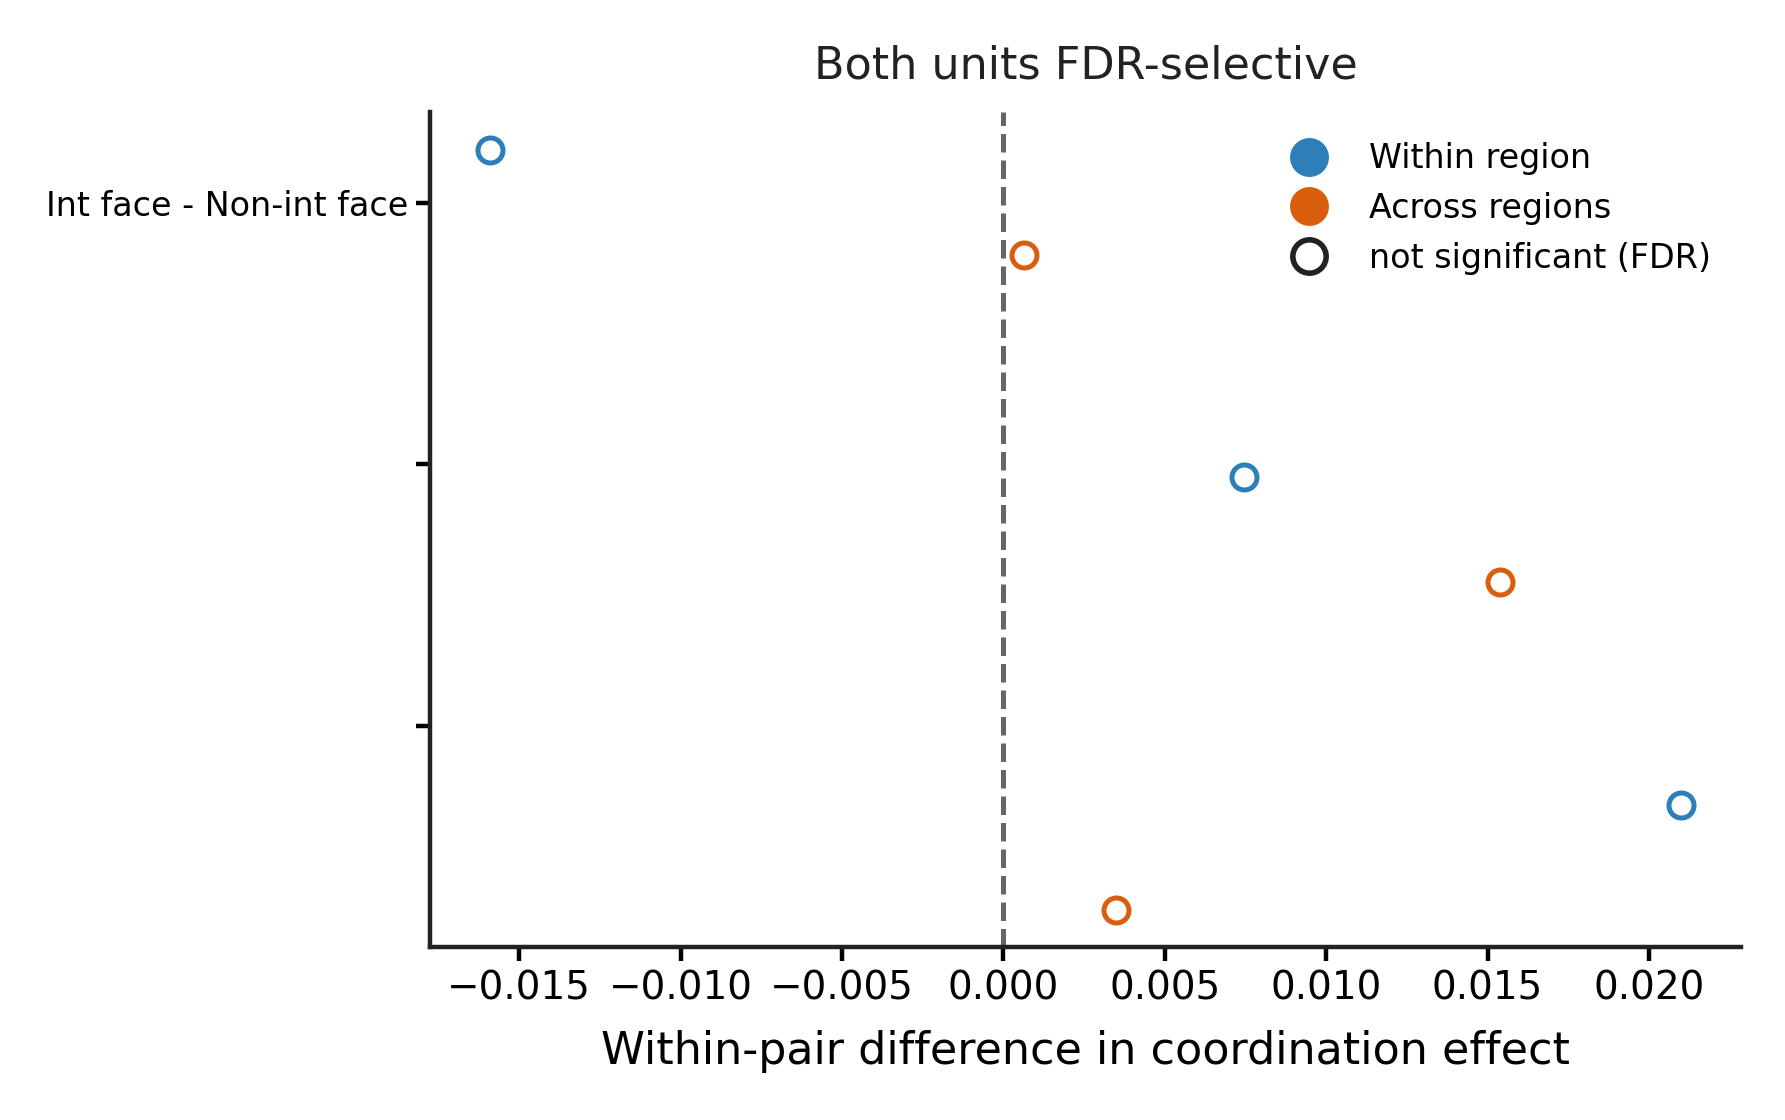

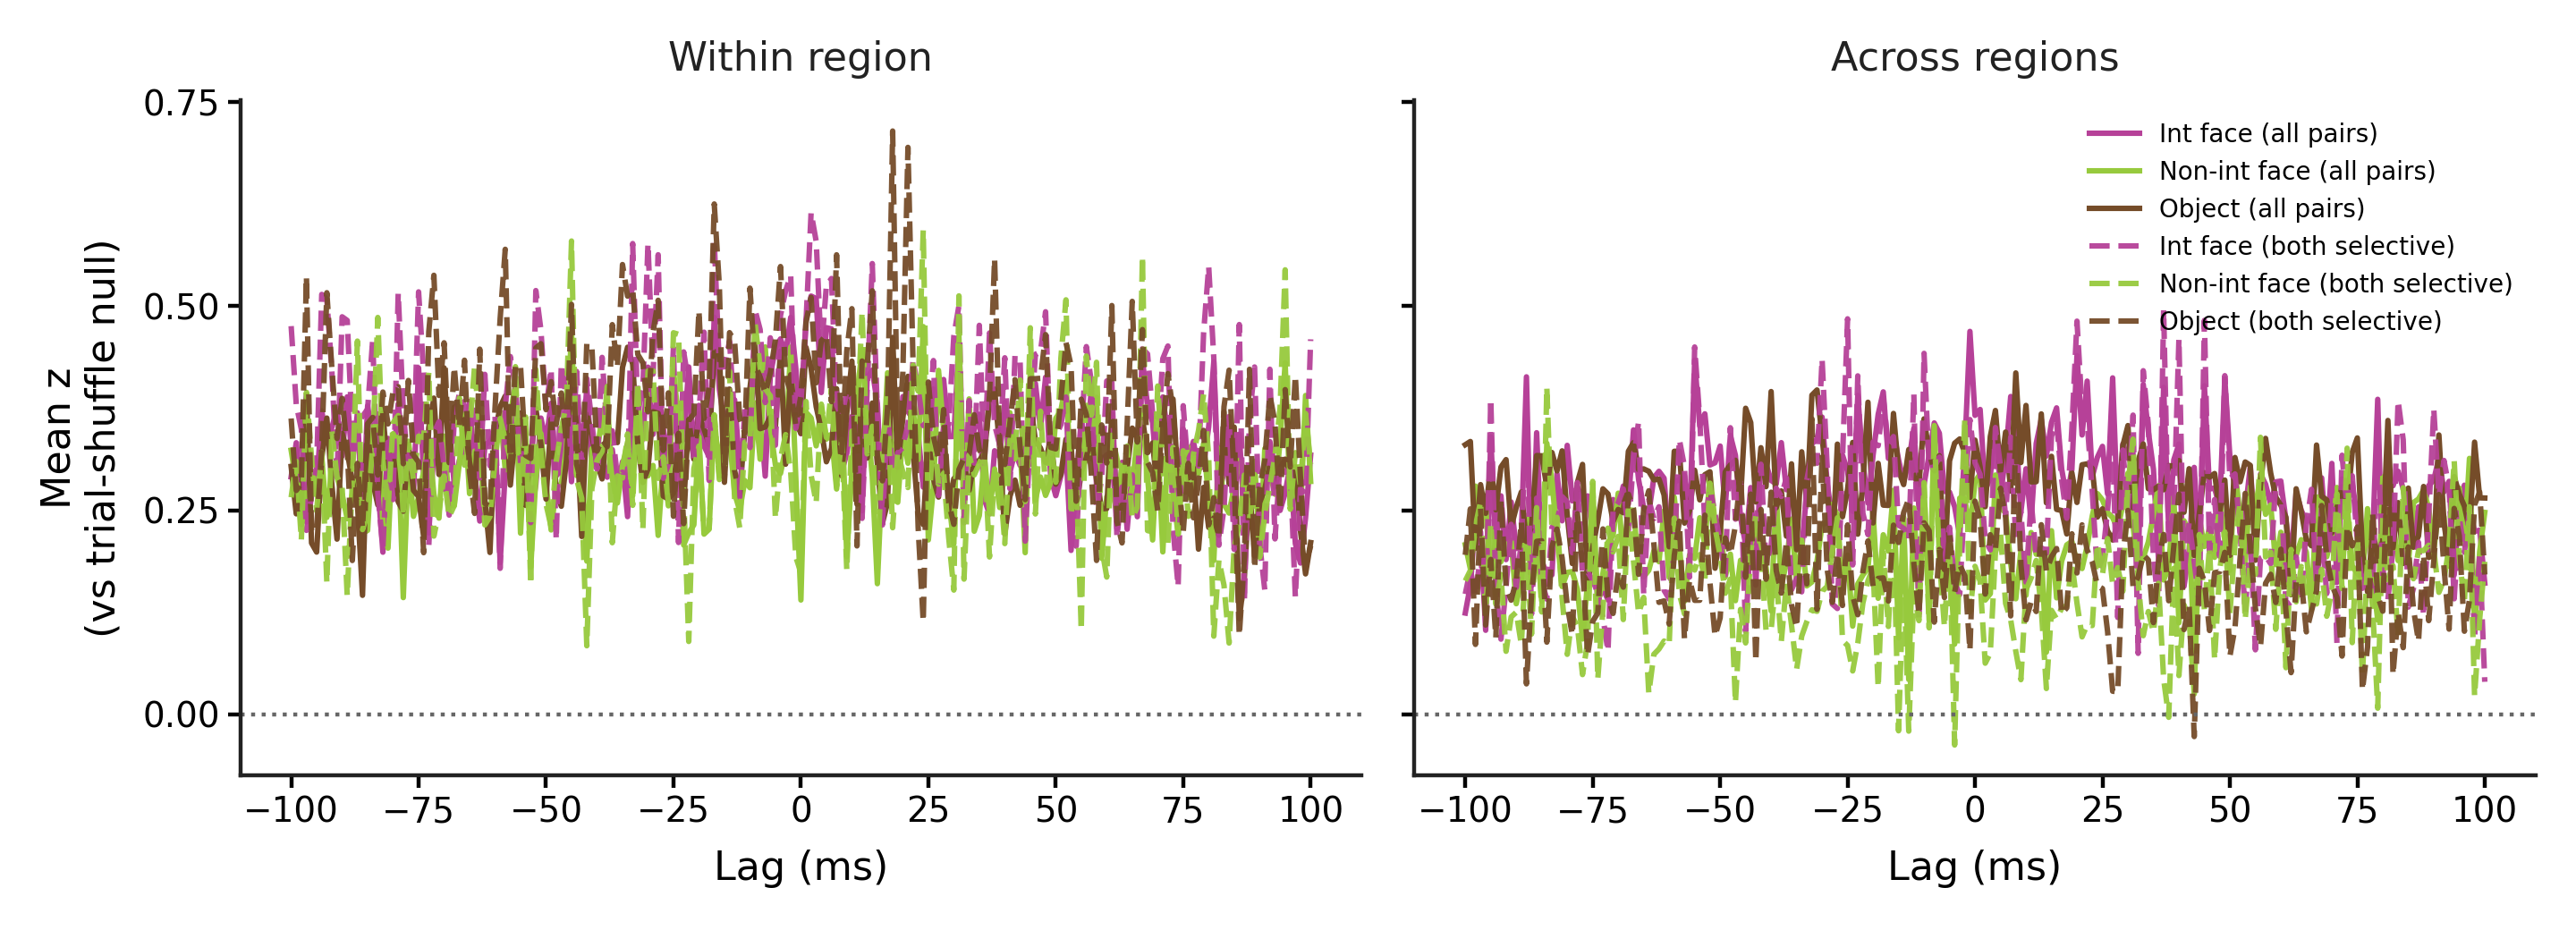

In [11]:
selective = pairs.loc[pairs["both_selective"]]
print(f"pairs with both units FDR-selective: {len(selective):,} of {len(pairs):,} "
      f"({len(selective) / max(len(pairs), 1):.1%})")

selective_comparisons = psc.compare_conditions(selective, metric=EFFECT_METRIC)
display(selective_comparisons.round(4))

fig, paths = viz.plot_condition_contrasts(
    selective_comparisons, fig_settings,
    label="Both units FDR-selective", stem="fig04c_condition_contrasts_selective",
)
display(Image(filename=str(paths["png"])))

selective_traces = pd.read_pickle(SUMMARY_DIR / "group_z_traces_selective.pkl")
fig, paths = viz.plot_selectivity_comparison(by_scope, selective_traces, fig_settings)
display(Image(filename=str(paths["png"])))

## 10. The zero-lag artifact

Earlier runs showed a sharp zero-lag peak on some days. That is almost certainly
**not** a pairwise interaction: the chance that two randomly sampled neurons are
monosynaptically connected is near zero, so a zero-lag peak shared by most pairs
on a day is common input — movement, arousal, or a shared reference/ground
artifact on the recording system.

The signature that separates an artifact from a real effect is that it is a
property of the **day and array**, not of the pair: on a contaminated day nearly
every simultaneously recorded pair shows it, including pairs sharing nothing
else. This flags such days as outliers instead of averaging them in.

,date,scope,n_pairs,mean_zero_lag_z,median_zero_lag_z,frac_pairs_zero_lag_above,mean_zero_lag_sharpness,suspected_zero_lag_artifact
0,01312018,cross_region,2440,0.1273,-0.2919,0.0373,0.0441,False
1,01312018,within_region,2237,0.0627,-0.3656,0.0443,-0.0501,False


_No date stands out as a zero-lag outlier._

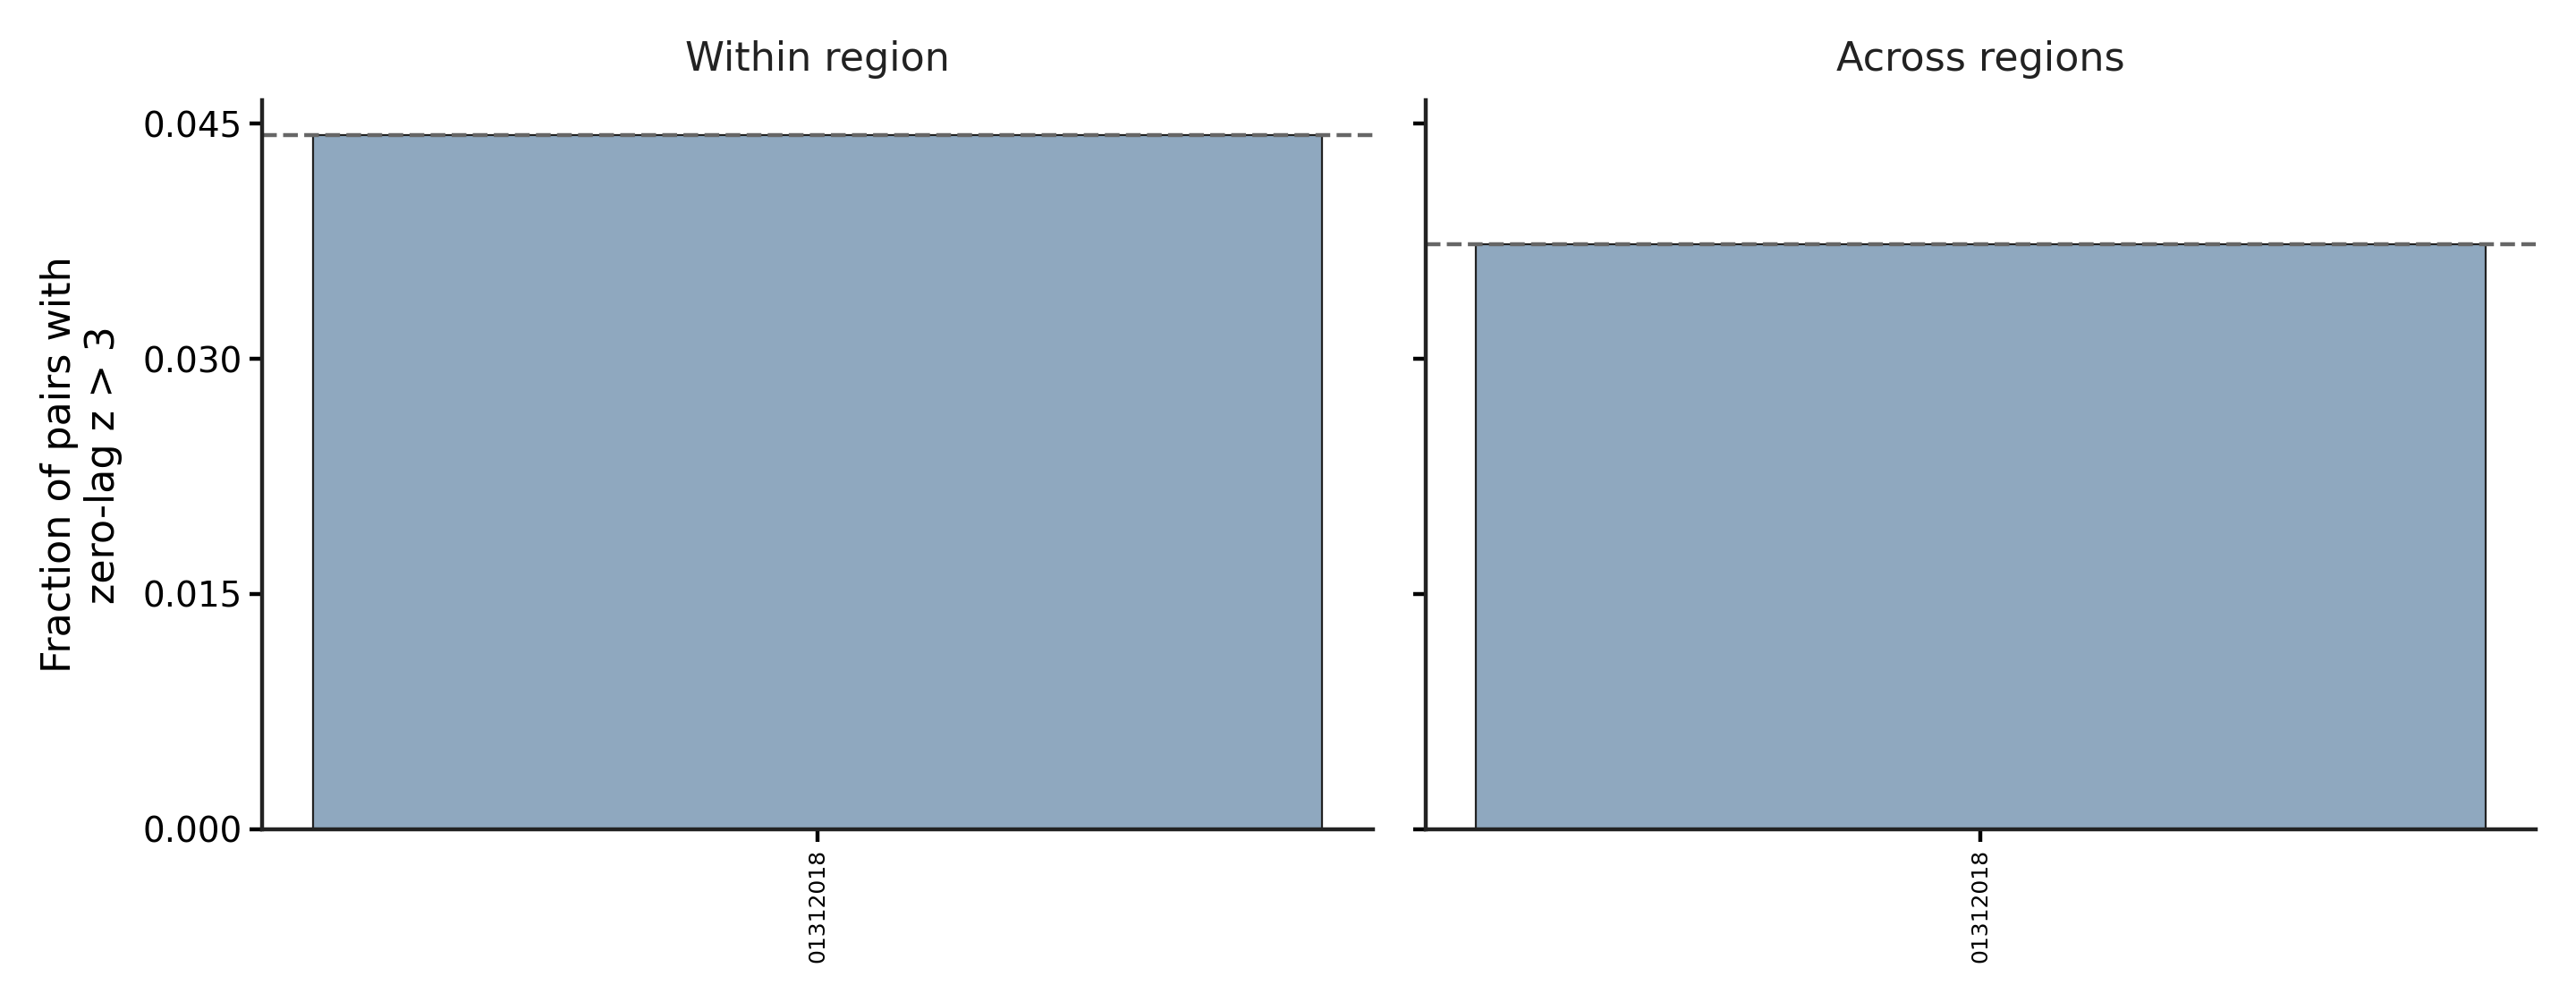

In [12]:
diagnostics = psc.build_zero_lag_diagnostics(pairs)
display(diagnostics.round(4))

flagged = diagnostics.loc[diagnostics["suspected_zero_lag_artifact"].fillna(False)]
if len(flagged):
    display(Markdown(
        f"**{len(flagged)} date/scope combinations flagged.** "
        f"Dates: {sorted(flagged['date'].unique())}"
    ))
else:
    display(Markdown("_No date stands out as a zero-lag outlier._"))

fig, paths = viz.plot_zero_lag_diagnostics(diagnostics, fig_settings)
display(Image(filename=str(paths["png"])))

## 11. Does the conclusion survive dropping flagged days?

The honest test of an artifact: remove the suspect days and see whether the
condition effects hold.

In [13]:
flagged_dates = set(
    psc.build_zero_lag_diagnostics(pairs)
    .pipe(lambda d: d.loc[d["suspected_zero_lag_artifact"].fillna(False), "date"])
    .astype(str)
)
if flagged_dates:
    clean = pairs.loc[~pairs["date"].astype(str).isin(flagged_dates)]
    print(f"dropping {len(flagged_dates)} flagged date(s): {sorted(flagged_dates)}")
    print(f"pairs remaining: {len(clean):,} of {len(pairs):,}")
    clean_comparisons = psc.compare_conditions(clean, metric=EFFECT_METRIC)
    display(clean_comparisons.round(4))
    display(Markdown(
        "If the condition effects above match the all-days result, the conclusion "
        "does not rest on the flagged days."
    ))
else:
    display(Markdown("_No days were flagged, so there is nothing to exclude._"))

_No days were flagged, so there is nothing to exclude._